Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

print("Libraries imported successfully")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully
TensorFlow version: 2.20.0


Step 2: Load CIFAR-10 Dataset

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing labels shape: (10000, 1)


Step 3: Display Original Images

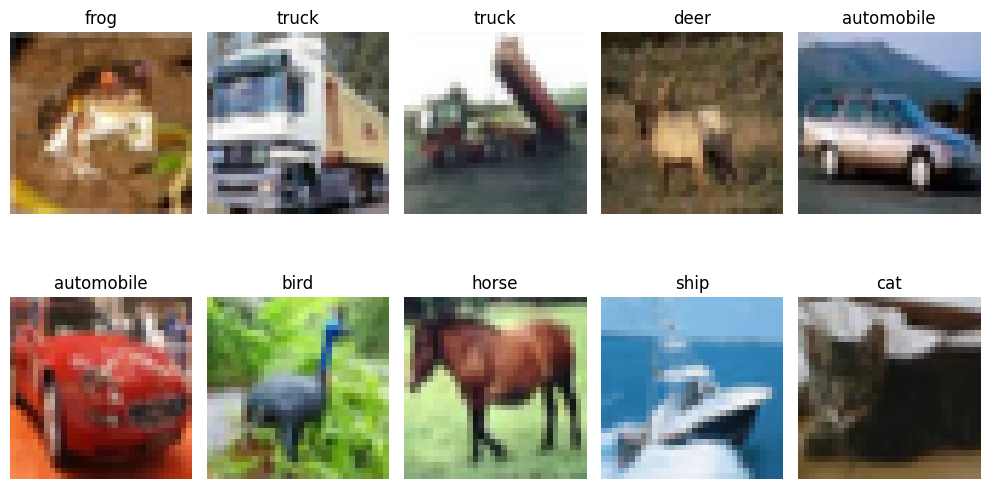

In [3]:
# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display sample images
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 4: Image Normalization

In [4]:
# Image Normalization

x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print("Original pixel range:", x_train.min(), "to", x_train.max())
print("Normalized pixel range:", x_train_normalized.min(), "to", x_train_normalized.max())

Original pixel range: 0 to 255
Normalized pixel range: 0.0 to 1.0


Step 5: Image Cropping

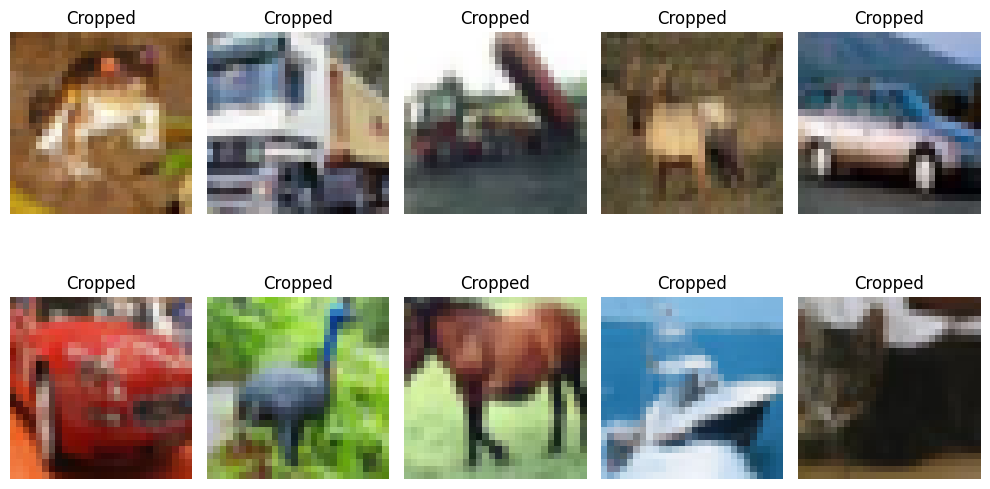

In [5]:
# Image Cropping

crop_layer = layers.RandomCrop(28, 28)

cropped_images = crop_layer(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cropped_images[i])
    plt.title("Cropped")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 6: Image Rotation

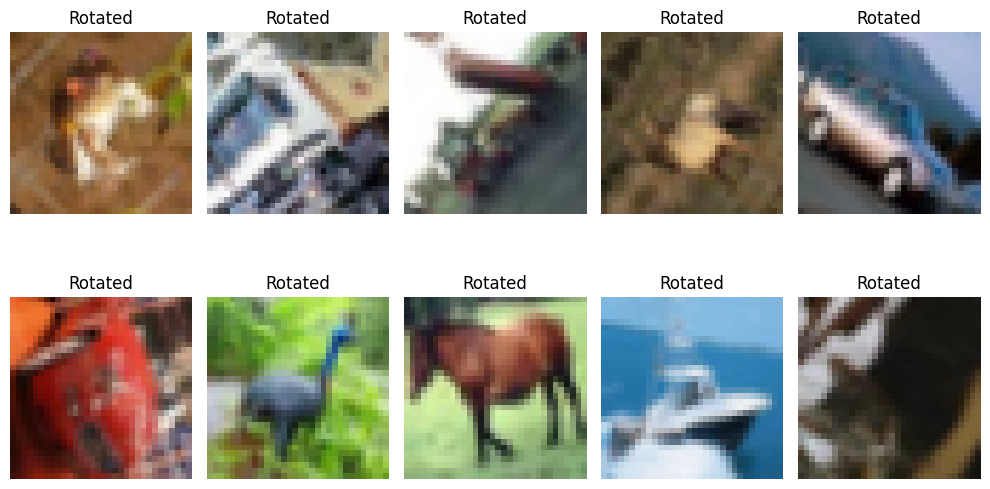

In [6]:
# Image Rotation

rotation_layer = layers.RandomRotation(0.2)

rotated_images = rotation_layer(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(rotated_images[i])
    plt.title("Rotated")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 7: Horizontal Flipping

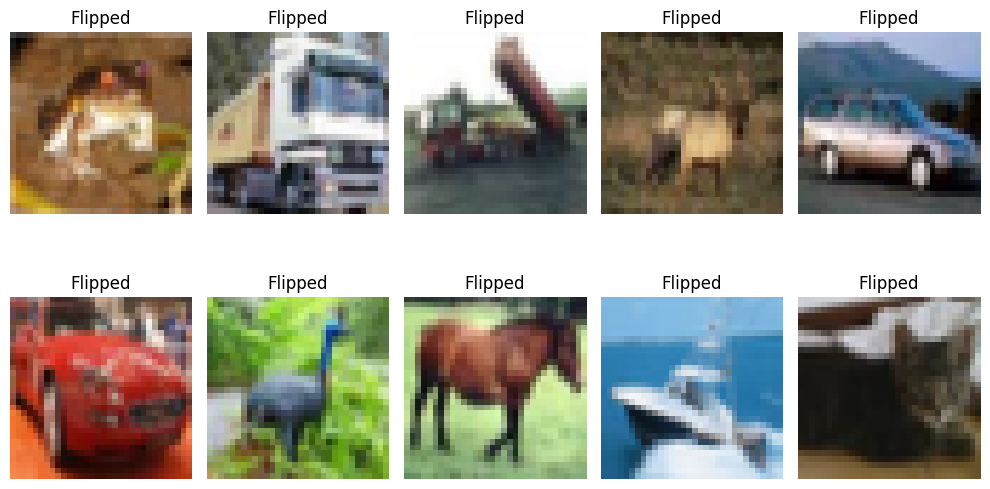

In [7]:
# Horizontal Flipping

flip_layer = layers.RandomFlip("horizontal")

flipped_images = flip_layer(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(flipped_images[i])
    plt.title("Flipped")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 8: Brightness Adjustment

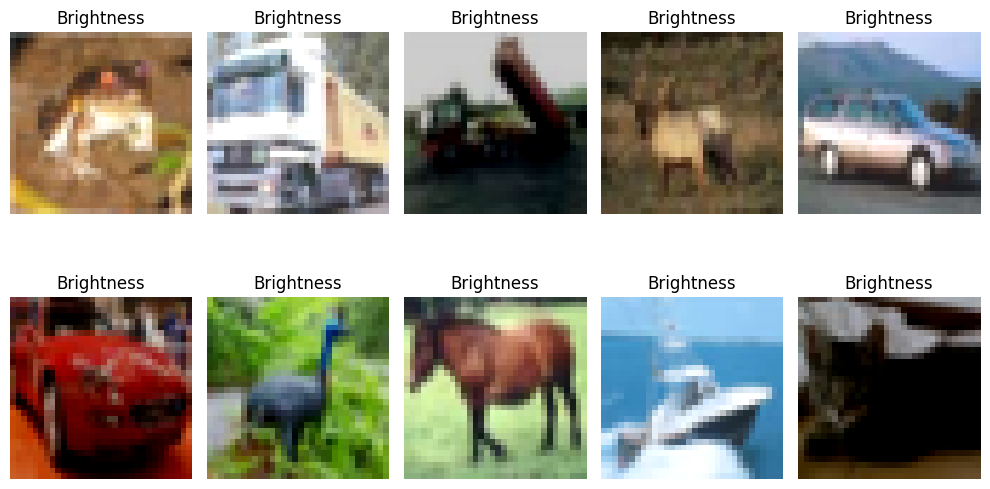

In [8]:
# Brightness Adjustment

brightness_layer = layers.RandomBrightness(
    factor=0.2,
    value_range=(0, 1)
)

bright_images = brightness_layer(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(bright_images[i])
    plt.title("Brightness")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 9: Contrast Adjustment

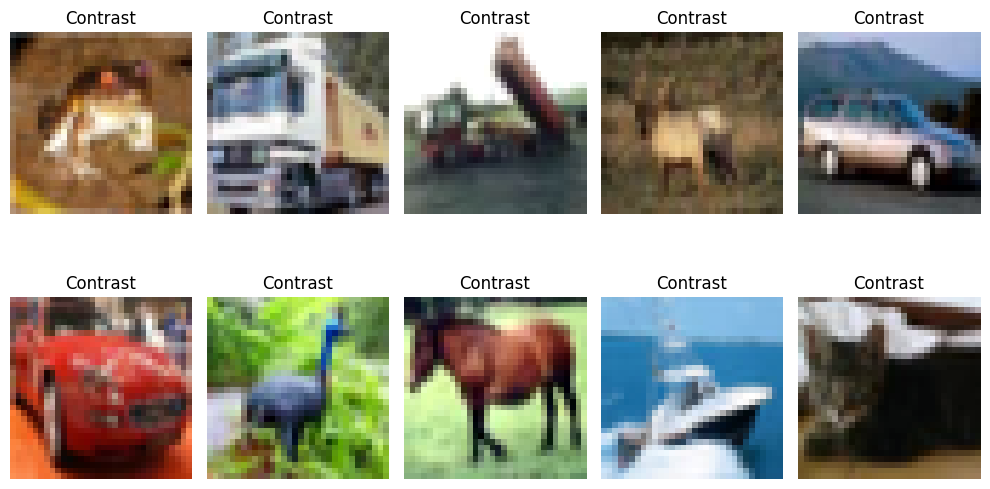

In [9]:
# Contrast Adjustment

contrast_layer = layers.RandomContrast(
    factor=0.2
)

contrast_images = contrast_layer(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(contrast_images[i])
    plt.title("Contrast")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 10: Color and Saturation Augmentation

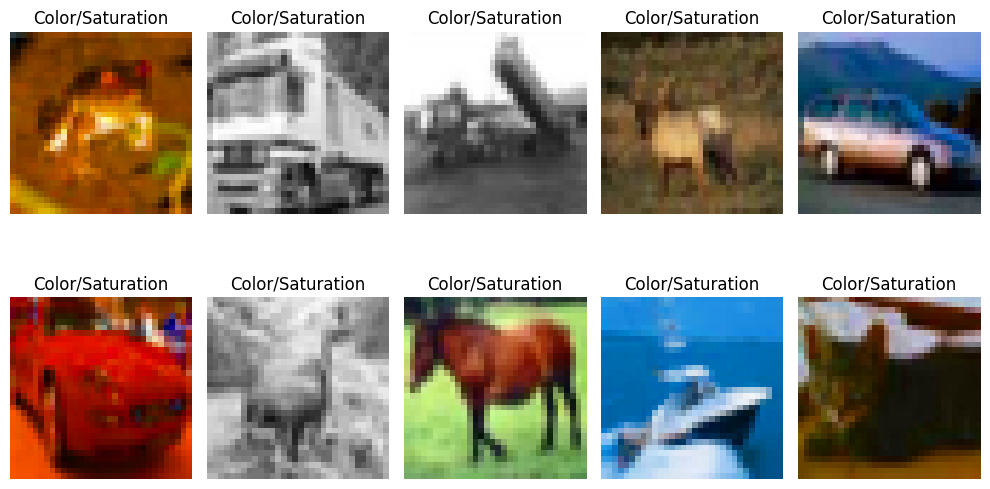

In [12]:
# Color and Saturation Augmentation

color_layer = tf.keras.Sequential([
    layers.RandomSaturation(factor=(0.5, 1.5), value_range=(0, 1))
])

color_images = color_layer(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(color_images[i])
    plt.title("Color/Saturation")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 11: Create Combined Data Augmentation Pipeline

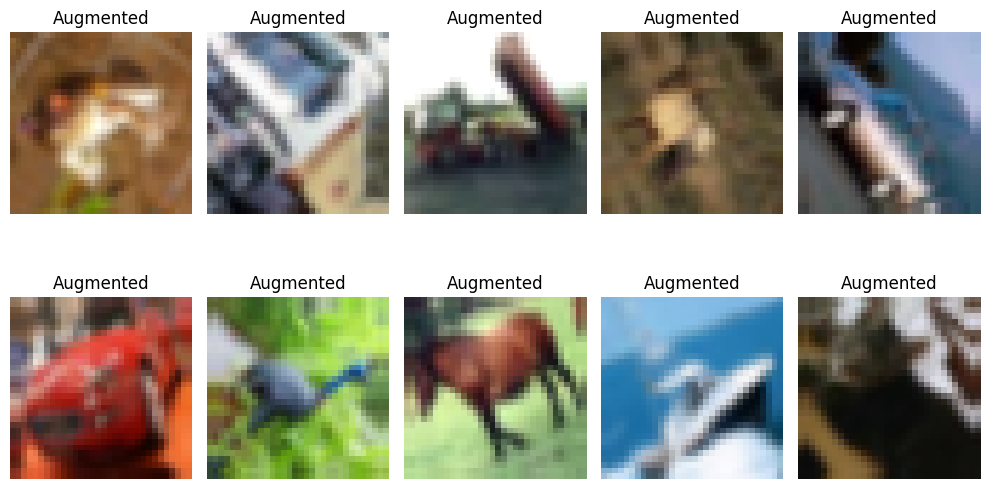

In [13]:
# Combined Data Augmentation Pipeline

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2)
])

augmented_images = data_augmentation(x_train_normalized[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_images[i])
    plt.title("Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 12: Build CNN Model

In [15]:
# Build CNN Model

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Step 13: Compile and Train CNN on Original Dataset

In [17]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model on original normalized images
history_original = model.fit(
    x_train_normalized,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.4141 - loss: 1.5981 - val_accuracy: 0.4778 - val_loss: 1.4356
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - accuracy: 0.5544 - loss: 1.2504 - val_accuracy: 0.5696 - val_loss: 1.1877
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.6192 - loss: 1.0872 - val_accuracy: 0.6066 - val_loss: 1.1428
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6561 - loss: 0.9795 - val_accuracy: 0.6528 - val_loss: 0.9802
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.6823 - loss: 0.9112 - val_accuracy: 0.6788 - val_loss: 0.9449


Step 14: Plot Training Accuracy and Loss

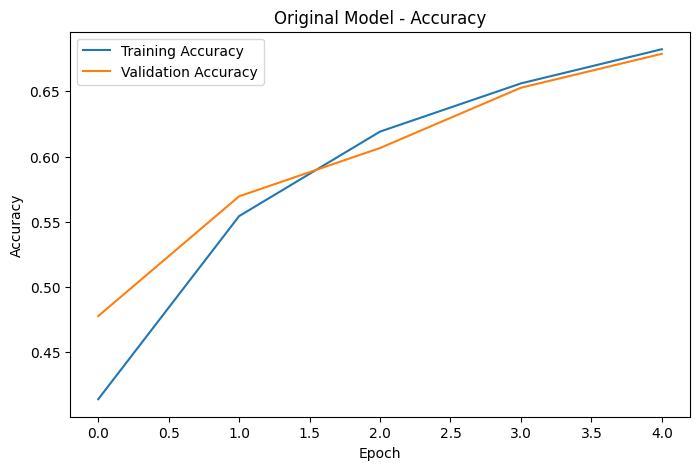

In [18]:
# Plot Training Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_original.history['accuracy'], label='Training Accuracy')
plt.plot(history_original.history['val_accuracy'], label='Validation Accuracy')

plt.title('Original Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

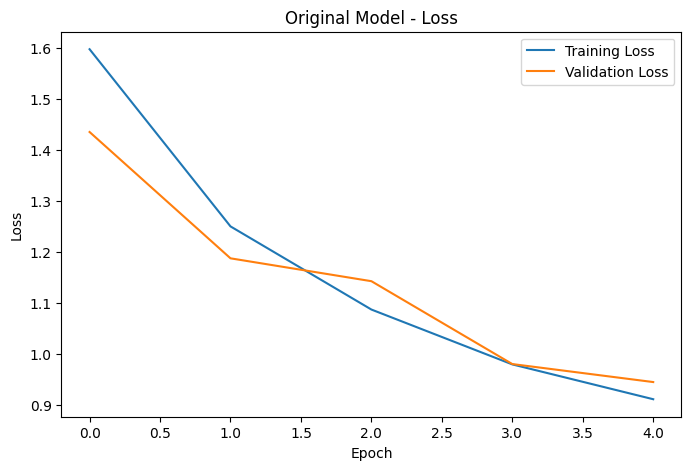

In [19]:
# Plot Training Loss

plt.figure(figsize=(8, 5))

plt.plot(history_original.history['loss'], label='Training Loss')
plt.plot(history_original.history['val_loss'], label='Validation Loss')

plt.title('Original Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Step 15: Evaluate Original Model

In [20]:
# Evaluate the original model

test_loss, test_accuracy = model.evaluate(
    x_test_normalized,
    y_test,
    verbose=1
)

print("Original Model Test Accuracy:", test_accuracy)
print("Original Model Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6578 - loss: 0.9802
Original Model Test Accuracy: 0.657800018787384
Original Model Test Loss: 0.9801695346832275


Step 16: Create CNN Model with Data Augmentation

In [21]:
# Create CNN Model with Data Augmentation

augmented_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),

    # CNN Layers
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

augmented_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Step 17: Compile and Train Augmented CNN

In [22]:
# Compile the augmented CNN model

augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the augmented model
history_augmented = augmented_model.fit(
    x_train_normalized,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - accuracy: 0.3351 - loss: 1.8230 - val_accuracy: 0.4056 - val_loss: 1.6342
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.4301 - loss: 1.5847 - val_accuracy: 0.4588 - val_loss: 1.5139
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.4694 - loss: 1.4756 - val_accuracy: 0.5030 - val_loss: 1.3893
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5013 - loss: 1.4075 - val_accuracy: 0.5262 - val_loss: 1.3122
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5212 - loss: 1.3399 - val_accuracy: 0.5726 - val_loss: 1.2131


Step 18: Plot Augmented Model Accuracy and Loss

18.1 Accuracy Graph

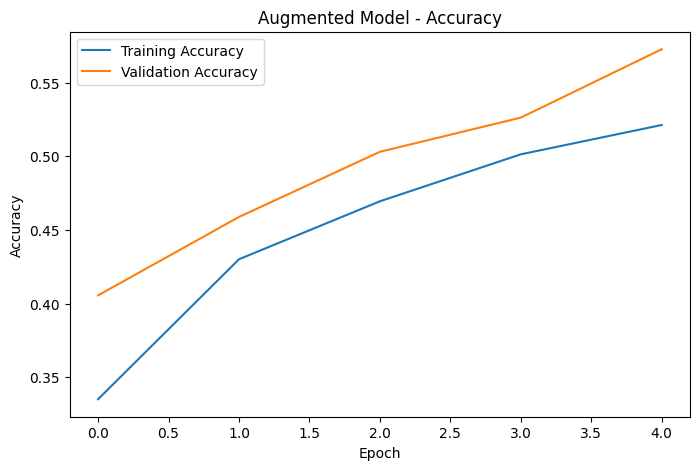

In [23]:
# Plot Augmented Model Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_augmented.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_augmented.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Augmented Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

18.2 Loss Graph

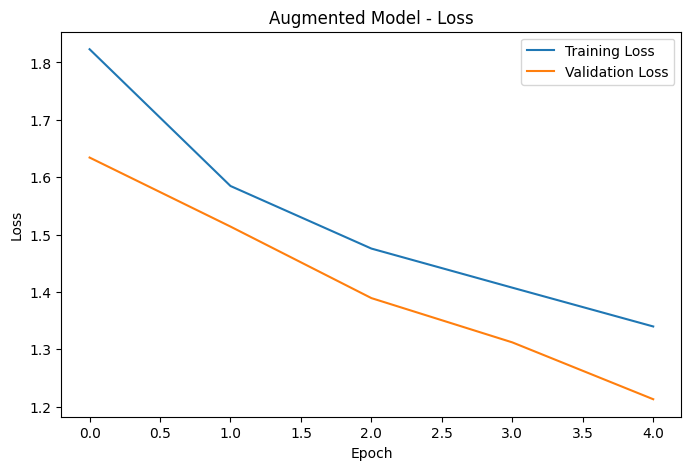

In [24]:
# Plot Augmented Model Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_augmented.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_augmented.history['val_loss'],
    label='Validation Loss'
)

plt.title('Augmented Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Step 19: Evaluate Augmented Model

In [25]:
# Evaluate the augmented model

augmented_test_loss, augmented_test_accuracy = augmented_model.evaluate(
    x_test_normalized,
    y_test,
    verbose=1
)

print("Augmented Model Test Accuracy:", augmented_test_accuracy)
print("Augmented Model Test Loss:", augmented_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5631 - loss: 1.2192
Augmented Model Test Accuracy: 0.5630999803543091
Augmented Model Test Loss: 1.219247579574585


Step 20: Compare Original vs Augmented Model

In [26]:
# Compare Model Performance

print("Performance Comparison")
print("----------------------")

print("Original Model Test Accuracy:",
      round(test_accuracy * 100, 2), "%")

print("Augmented Model Test Accuracy:",
      round(augmented_test_accuracy * 100, 2), "%")

print()

print("Original Model Test Loss:",
      round(test_loss, 4))

print("Augmented Model Test Loss:",
      round(augmented_test_loss, 4))

Performance Comparison
----------------------
Original Model Test Accuracy: 65.78 %
Augmented Model Test Accuracy: 56.31 %

Original Model Test Loss: 0.9802
Augmented Model Test Loss: 1.2192


In [27]:
# Create Performance Comparison Table

comparison = {
    'Model': ['Original CNN', 'Augmented CNN'],
    'Test Accuracy (%)': [
        round(test_accuracy * 100, 2),
        round(augmented_test_accuracy * 100, 2)
    ],
    'Test Loss': [
        round(test_loss, 4),
        round(augmented_test_loss, 4)
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Test Accuracy (%),Test Loss
0,Original CNN,65.78,0.9802
1,Augmented CNN,56.31,1.2192


Step 21: Create Performance Comparison Graph

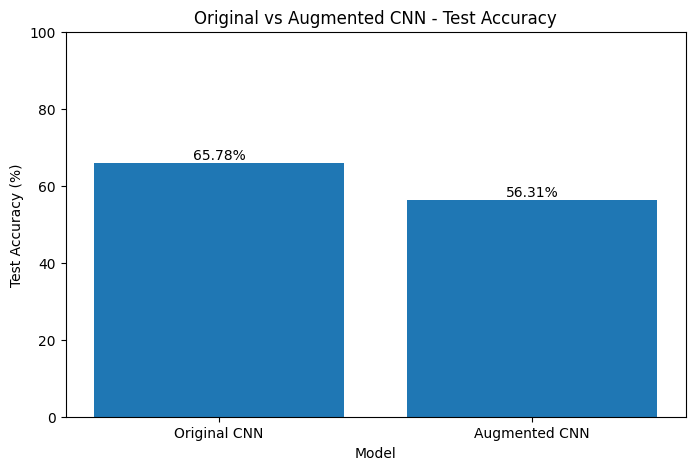

In [28]:
# Compare Test Accuracy

models_name = ['Original CNN', 'Augmented CNN']
accuracy_values = [
    test_accuracy * 100,
    augmented_test_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(models_name, accuracy_values)

plt.title('Original vs Augmented CNN - Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)

for i, value in enumerate(accuracy_values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.show()

Step 22: Original vs Augmented Images

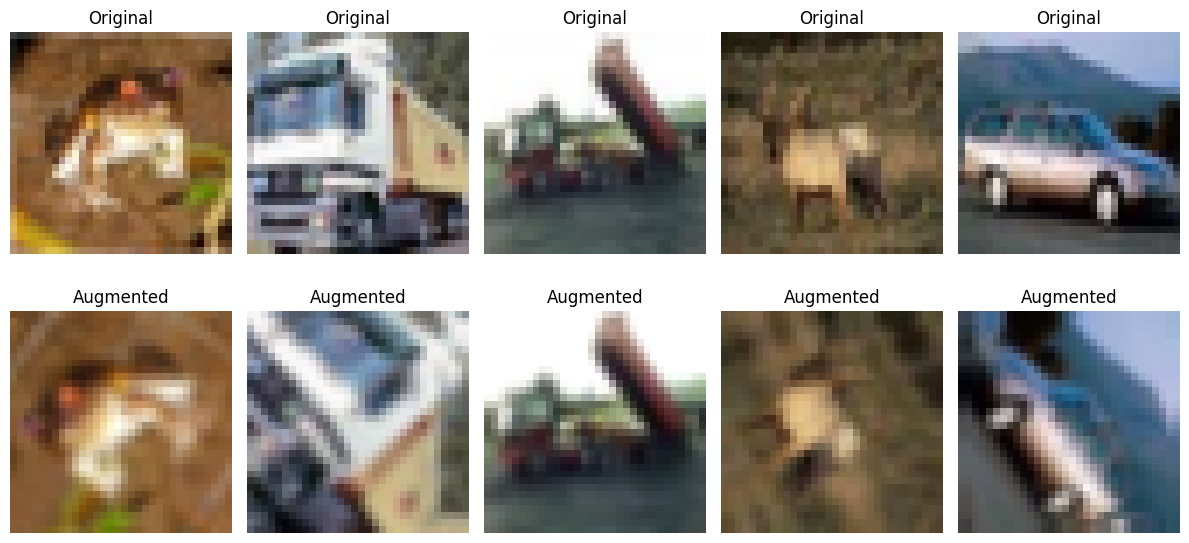

In [29]:
# Original vs Augmented Images

plt.figure(figsize=(12, 6))

for i in range(5):
    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_normalized[i])
    plt.title("Original")
    plt.axis('off')

    # Augmented image
    plt.subplot(2, 5, i + 6)
    plt.imshow(augmented_images[i])
    plt.title("Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 23: Final Performance Analysis

In [30]:
# Final Performance Analysis

accuracy_change = (
    augmented_test_accuracy - test_accuracy
) * 100

loss_change = augmented_test_loss - test_loss

print("Original CNN Accuracy:",
      round(test_accuracy * 100, 2), "%")

print("Augmented CNN Accuracy:",
      round(augmented_test_accuracy * 100, 2), "%")

print("Change in Accuracy:",
      round(accuracy_change, 2), "percentage points")

print()

print("Original CNN Loss:",
      round(test_loss, 4))

print("Augmented CNN Loss:",
      round(augmented_test_loss, 4))

print("Change in Loss:",
      round(loss_change, 4))

Original CNN Accuracy: 65.78 %
Augmented CNN Accuracy: 56.31 %
Change in Accuracy: -9.47 percentage points

Original CNN Loss: 0.9802
Augmented CNN Loss: 1.2192
Change in Loss: 0.2391


Step 24: Create Final Visualization Report

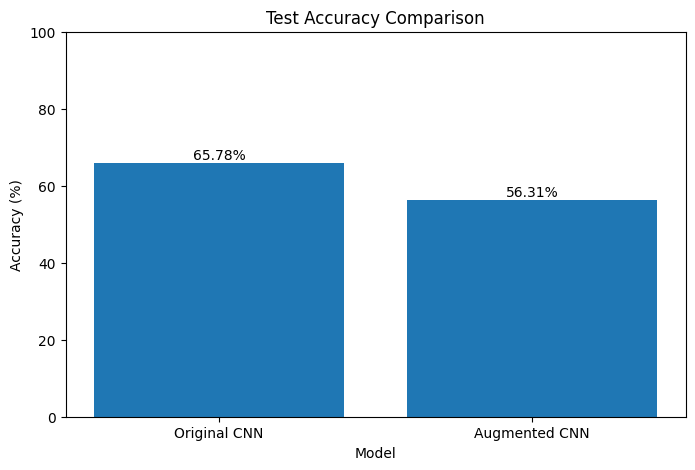

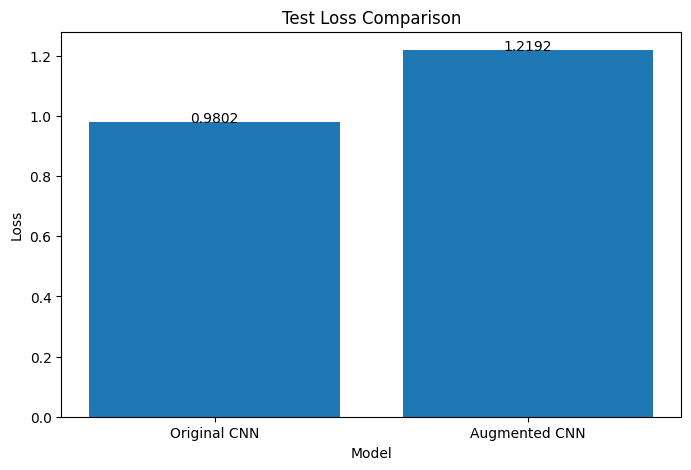

In [31]:
# Final Performance Visualization

model_names = ['Original CNN', 'Augmented CNN']

accuracy_values = [
    test_accuracy * 100,
    augmented_test_accuracy * 100
]

loss_values = [
    test_loss,
    augmented_test_loss
]

# Accuracy Graph
plt.figure(figsize=(8, 5))

plt.bar(model_names, accuracy_values)

plt.title('Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, value in enumerate(accuracy_values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.show()


# Loss Graph
plt.figure(figsize=(8, 5))

plt.bar(model_names, loss_values)

plt.title('Test Loss Comparison')
plt.xlabel('Model')
plt.ylabel('Loss')

for i, value in enumerate(loss_values):
    plt.text(i, value, f'{value:.4f}', ha='center')

plt.show()

Step 25 — Create the Complete Augmentation Pipeline

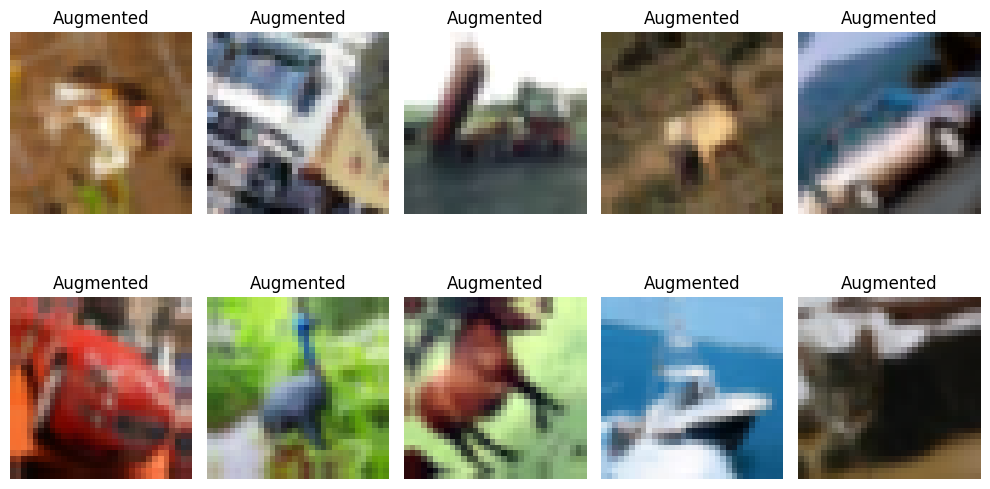

In [32]:
# Complete Data Augmentation Pipeline

data_augmentation_complete = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2)
])

# Apply augmentation to sample images
complete_augmented_images = data_augmentation_complete(
    x_train_normalized[:10]
)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(complete_augmented_images[i])
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 26: Create Final Results Table

In [33]:
# Final Results Table

results = pd.DataFrame({
    'Model': ['Original CNN', 'Augmented CNN'],
    'Test Accuracy (%)': [
        round(test_accuracy * 100, 2),
        round(augmented_test_accuracy * 100, 2)
    ],
    'Test Loss': [
        round(test_loss, 4),
        round(augmented_test_loss, 4)
    ]
})

print("Final Performance Comparison")
results

Final Performance Comparison


,Model,Test Accuracy (%),Test Loss
0,Original CNN,65.78,0.9802
1,Augmented CNN,56.31,1.2192


Step 27 — Automatic Observation

In [34]:
print("OBSERVATION")
print("-----------")

if augmented_test_accuracy > test_accuracy:
    improvement = (augmented_test_accuracy - test_accuracy) * 100
    print(f"Augmented CNN improved test accuracy by {improvement:.2f} percentage points.")
elif augmented_test_accuracy < test_accuracy:
    difference = (test_accuracy - augmented_test_accuracy) * 100
    print(f"Augmented CNN test accuracy was lower by {difference:.2f} percentage points.")
else:
    print("Both models achieved the same test accuracy.")

if augmented_test_loss < test_loss:
    loss_reduction = test_loss - augmented_test_loss
    print(f"Augmented CNN reduced test loss by {loss_reduction:.4f}.")
elif augmented_test_loss > test_loss:
    loss_increase = augmented_test_loss - test_loss
    print(f"Augmented CNN test loss was higher by {loss_increase:.4f}.")
else:
    print("Both models achieved the same test loss.")

OBSERVATION
-----------
Augmented CNN test accuracy was lower by 9.47 percentage points.
Augmented CNN test loss was higher by 0.2391.


Step 28 — Augmentation Techniques Summary

In [35]:
augmentation_techniques = pd.DataFrame({
    'Technique': [
        'Image Normalization',
        'Cropping',
        'Rotation',
        'Horizontal Flipping',
        'Brightness Adjustment',
        'Contrast Adjustment',
        'Color/Saturation Adjustment'
    ],
    'Purpose': [
        'Scale pixel values between 0 and 1',
        'Focus on different parts of the image',
        'Improve robustness to rotated images',
        'Handle horizontally flipped images',
        'Handle different lighting conditions',
        'Handle different contrast levels',
        'Improve robustness to color variations'
    ]
})

augmentation_techniques

,Technique,Purpose
0,Image Normalization,Scale pixel values between 0 and 1
1,Cropping,Focus on different parts of the image
2,Rotation,Improve robustness to rotated images
3,Horizontal Flipping,Handle horizontally flipped images
4,Brightness Adjustment,Handle different lighting conditions
5,Contrast Adjustment,Handle different contrast levels
6,Color/Saturation Adjustment,Improve robustness to color variations


Step 29 —  Conclusion

In this project, image preprocessing and data augmentation techniques were applied to the CIFAR-10 dataset. Different techniques such as normalization, cropping, rotation, flipping, brightness, contrast, and color/saturation adjustment were explored.

Two CNN models were trained and their performance was compared using test accuracy and test loss. The project helped demonstrate how data augmentation creates different variations of images and can improve the model's ability to generalize to unseen data.

Overall, this project provided practical understanding of image preprocessing, data augmentation, CNN model training, and performance evaluation in deep learning.


Step 30 — Final Project Summary


This project was implemented using the **CIFAR-10 image dataset** and a **Convolutional Neural Network (CNN)**. Image preprocessing and data augmentation techniques such as **normalization, cropping, rotation, horizontal flipping, brightness adjustment, contrast adjustment, and color/saturation adjustment** were explored.

Two CNN models were used for comparison: an **Original CNN** and an **Augmented CNN**. The models were evaluated using **test accuracy and test loss**.

The results were compared to understand how data augmentation affects the performance and generalization of a deep learning model. The project demonstrates that image augmentation can create variations in training images and help a model handle different image conditions.
